# K12_06 – Anomalieerkennung: Kreditkartenbetrug
**Maschinelles Lernen mit Python · Kapitel 12: Anomalieerkennung**

Update am 27. Mai 2026

---

## Einordnung

In **K06_05** haben wir XGBoost als Ensemble-Methode kennengelernt und
seine Hyperparameter, `scale_pos_weight`, ROC-Kurven und SHAP-Werte
am Fraud-Datensatz studiert.

Dieses Notebook hat eine andere Perspektive: **XGBoost ist hier nur das Werkzeug.**
Die eigentliche Frage lautet:

> *Wie erkennt man Anomalien in extrem unbalancierten Daten –
> und wie bewertet man ein solches Modell korrekt?*

---

## Was ist eine Anomalie?

Eine **Anomalie** (auch: Ausreißer, Outlier) ist ein Datenpunkt, der stark
vom erwarteten Muster abweicht. In der Betrugserkennung gilt:

- **Normale Transaktionen:** überwältigende Mehrheit (~99,83 %)
- **Betrugsfälle:** seltene Ausnahmen (~0,17 %) → das sind die Anomalien

Das macht dieses Problem fundamental anders als einen ausgeglichenen
Klassifikationsfall. Standard-ML-Metriken wie **Accuracy versagen hier** –
warum, sehen wir gleich konkret.

---

## Lernziele

Nach diesem Notebook können Sie:
- erklären, warum **Accuracy** bei Anomalieerkennung eine irreführende Metrik ist
- **Precision, Recall und F1-Score** aus einer Konfusionsmatrix manuell berechnen
- den Unterschied zwischen **False Negative** und **False Positive** domänenspezifisch bewerten
- ein **Dummy-Modell** als Referenz einsetzen, um Modellgüte einzuordnen
- die Verbindung zwischen Anomalieerkennung und klassischer Klassifikation herstellen


## 1. Bibliotheken importieren


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)
from xgboost import XGBClassifier

# Hinweis: XGBoost wurde in K06_05 ausfuehrlich eingefuehrt.
# Hier verwenden wir es als bekanntes Werkzeug ohne nochmalige Erklaerung
# der Hyperparameter.


## 2. Datensatz laden

Wir verwenden denselben Datensatz wie in K06_05: den **Kreditkartenbetrugs-Datensatz**
der Université Libre de Bruxelles.

| Spalte | Beschreibung |
|---|---|
| **V1–V28** | PCA-transformierte, anonymisierte Features (Datenschutz) |
| **Time** | Sekunden seit der ersten Transaktion |
| **Amount** | Transaktionsbetrag in Euro |
| **Class** | Zielspalte: 0 = normal, 1 = Betrug |

> **Warum PCA?** Die echten Features sind aus Datenschutzgründen anonymisiert.
> PCA komprimiert die Originaldaten in 28 Komponenten, die keine Rückschlüsse
> auf Kontonummern oder Kundendaten erlauben.


In [ ]:
import kagglehub, os

# Datensatz automatisch herunterladen (kein manuelles Upload nötig)
path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

print(f"Datensatz geladen: {df.shape[0]:,} Zeilen, {df.shape[1]} Spalten")
df.head(3)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Datensatz geladen: 284,807 Zeilen, 31 Spalten


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 3. Das Kernproblem: extremes Klassenungleichgewicht

Bevor wir ein Modell trainieren, schauen wir uns die Klassenverteilung an.
Das ist bei Anomalieerkennung der erste und wichtigste Schritt.


Klassenverteilung:
  Normale Transaktionen (0): 284,315
  Betrugsfaelle         (1):     492
  Betrugsanteil:             0.173%

Denkaufgabe: Ein Modell, das IMMER 'kein Betrug' sagt,
  erreicht 99.827% Accuracy -- und erkennt keinen einzigen Betrugsfall!
  -> Dieses Accuracy-Paradoxon untersuchen wir in Aufgabe 3.


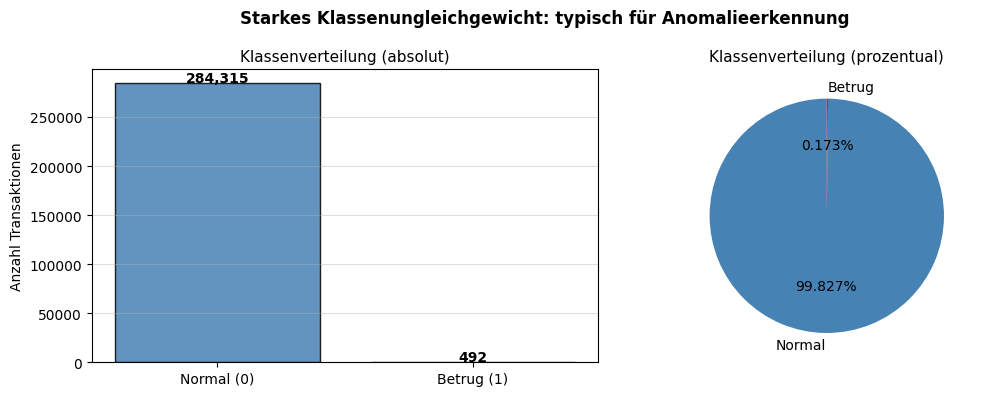

In [ ]:
# Klassenverteilung analysieren
verteilung = df['Class'].value_counts()
betrug_anteil = verteilung[1] / len(df) * 100
trivial_acc   = verteilung[0] / len(df) * 100

print("Klassenverteilung:")
print(f"  Normale Transaktionen (0): {verteilung[0]:>7,}")
print(f"  Betrugsfaelle         (1): {verteilung[1]:>7,}")
print(f"  Betrugsanteil:             {betrug_anteil:.3f}%")
print()
print("Denkaufgabe: Ein Modell, das IMMER 'kein Betrug' sagt,")
print(f"  erreicht {trivial_acc:.3f}% Accuracy -- und erkennt keinen einzigen Betrugsfall!")
print("  -> Dieses Accuracy-Paradoxon untersuchen wir in Aufgabe 3.")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Normal (0)', 'Betrug (1)'], verteilung.values,
            color=['steelblue', 'crimson'], edgecolor='black', alpha=0.85)
axes[0].set_title('Klassenverteilung (absolut)', fontsize=11)
axes[0].set_ylabel('Anzahl Transaktionen')
for i, v in enumerate(verteilung.values):
    axes[0].text(i, v + 800, f'{v:,}', ha='center', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.4)

axes[1].pie([verteilung[0], verteilung[1]],
            labels=['Normal', 'Betrug'],
            colors=['steelblue', 'crimson'],
            autopct='%1.3f%%', startangle=90)
axes[1].set_title('Klassenverteilung (prozentual)', fontsize=11)

plt.suptitle('Starkes Klassenungleichgewicht: typisch für Anomalieerkennung',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Train/Test-Split

`stratify=y` ist hier besonders wichtig: ohne Stratifizierung könnte der
Test-Split zufällig kaum Betrugsfälle enthalten – wir würden an einem
verzerrten Testset evaluieren.


In [ ]:
y = df['Class']
X = df.drop('Class', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # gleiche Betrugsrate in Train und Test!
)

print(f"Trainingsdaten: {X_train.shape[0]:,} Transaktionen")
print(f"Testdaten:      {X_test.shape[0]:,} Transaktionen")
print(f"Betrug im Test: {y_test.sum()} Fälle ({y_test.sum()/len(y_test)*100:.3f}%)")


Trainingsdaten: 227,845 Transaktionen
Testdaten:      56,962 Transaktionen
Betrug im Test: 98 Fälle (0.172%)


## 5. XGBoost als Baseline trainieren

Wir trainieren XGBoost mit den **Standard-Parametern** – ohne `scale_pos_weight`
oder andere Anpassungen ans Klassenungleichgewicht. Das ist bewusst so:
Wir wollen zunächst sehen, wie gut ein unkonfiguriertes Modell abschneidet.

> **Verbindung zu K06_05:** Dort haben wir `scale_pos_weight` eingesetzt,
> um das Klassenungleichgewicht direkt im Modell zu behandeln. Hier interessiert
> uns die Frage: *Reicht XGBoost auch ohne diese Anpassung aus?*
> Die Metriken in Abschnitt 6 werden Antwort geben.


In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # unterdrueckt Warnungen in Colab
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("Training abgeschlossen.")


Training abgeschlossen.


## 6. Warum Accuracy hier versagt

Der erste Blick auf die Accuracy kann täuschen:


In [ ]:
acc = accuracy_score(y_test, y_pred)
trivial = y_test.value_counts()[0] / len(y_test)

print(f"Accuracy XGBoost:     {acc*100:.4f}%")
print(f"Accuracy Dummy-Modell:{trivial*100:.4f}%  (sagt immer 'kein Betrug')")
print()
print("Der Unterschied ist winzig -- aber die Modelle sind himmelweit verschieden.")
print("Accuracy ist hier keine aussagekraeftige Metrik.")
print("Wir brauchen Precision, Recall und F1-Score.")


Accuracy XGBoost:     99.9438%
Accuracy Dummy-Modell:99.8280%  (sagt immer 'kein Betrug')

Der Unterschied ist winzig -- aber die Modelle sind himmelweit verschieden.
Accuracy ist hier keine aussagekraeftige Metrik.
Wir brauchen Precision, Recall und F1-Score.


## 7. Konfusionsmatrix und Metriken

Die Konfusionsmatrix zeigt die vier möglichen Ergebnis-Typen:

| | Vorhergesagt: Normal | Vorhergesagt: Betrug |
|---|---|---|
| **Wahr: Normal** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Wahr: Betrug** | False Negative (FN) ❌ | True Positive (TP) ✅ |

**Was ist schlimmer – FN oder FP?**
- **FN:** Echten Betrug übersehen → finanzieller Schaden, Haftungsrisiko
- **FP:** Normale Transaktion blockiert → ärgerlich für den Kunden, aber behebbar

In der Betrugserkennung ist **Recall (FN minimieren) meist wichtiger** als Precision.
Der **F1-Score** balanciert beide Aspekte.


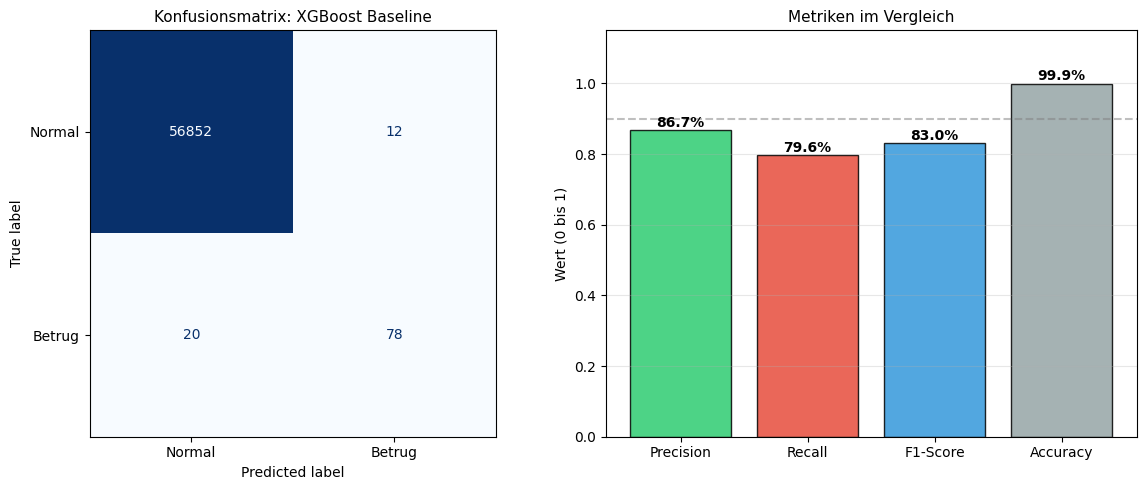

Konfusionsmatrix Detail:
  True Negative  (TN): 56,852  korrekt als normal erkannt
  True Positive  (TP):     78    korrekt als Betrug erkannt
  False Negative (FN):     20    Betrug NICHT erkannt  <- kritisch!
  False Positive (FP):     12    faelschlich als Betrug markiert

Precision: 86.67%  (von 90 als Betrug markierten: 78 wirklich Betrug)
Recall:    79.59%   (von 98 echten Betruegen: 78 erkannt)
F1-Score:  82.98%


In [ ]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Konfusionsmatrix
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Betrug']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Konfusionsmatrix: XGBoost Baseline', fontsize=11)

# Metriken
namen  = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
werte  = [precision, recall, f1, acc]
farben = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']
bars = axes[1].bar(namen, werte, color=farben, edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Metriken im Vergleich', fontsize=11)
axes[1].set_ylabel('Wert (0 bis 1)')
for bar, val in zip(bars, werte):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].axhline(0.9, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Konfusionsmatrix Detail:")
print(f"  True Negative  (TN): {TN:>6,}  korrekt als normal erkannt")
print(f"  True Positive  (TP): {TP:>6,}    korrekt als Betrug erkannt")
print(f"  False Negative (FN): {FN:>6,}    Betrug NICHT erkannt  <- kritisch!")
print(f"  False Positive (FP): {FP:>6,}    faelschlich als Betrug markiert")
print()
print(f"Precision: {precision*100:.2f}%  "
      f"(von {TP+FP} als Betrug markierten: {TP} wirklich Betrug)")
print(f"Recall:    {recall*100:.2f}%   "
      f"(von {TP+FN} echten Betruegen: {TP} erkannt)")
print(f"F1-Score:  {f1*100:.2f}%")


## 8. Übungen

### Aufgabe 1 – Metriken manuell berechnen
Berechnen Sie Precision, Recall und F1-Score aus der Konfusionsmatrix
(TN, TP, FN, FP) manuell mit den Formeln aus den Folien.
Vergleichen Sie Ihr Ergebnis mit dem Code-Output aus Abschnitt 7.

```
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1-Score  = 2 × (Precision × Recall) / (Precision + Recall)
```

### Aufgabe 2 – Kostenanalyse
Welcher Fehler ist teurer: False Negative oder False Positive?
Begründen Sie aus zwei Perspektiven:
(a) aus Sicht der Bank, (b) aus Sicht des Kunden.

### Aufgabe 3 – Das Accuracy-Paradoxon
Erstellen Sie ein Dummy-Modell, das für jede Transaktion immer
`0` (kein Betrug) vorhersagt. Berechnen Sie dessen Accuracy, Precision
und Recall. Was zeigt Ihnen dieses Experiment über die Aussagekraft
von Accuracy bei Anomalieerkennung?


In [ ]:
# Ihr Code hier

# Aufgabe 1: Metriken manuell berechnen
# TN, FP, FN, TP = cm.ravel()
# precision_manuell = ...
# recall_manuell    = ...
# f1_manuell        = ...

# Aufgabe 3: Dummy-Modell
# y_dummy = ...


---
## Musterlösungen

### Aufgabe 1 – Metriken manuell


In [ ]:
# Musterloesung Aufgabe 1
TN, FP, FN, TP = cm.ravel()

precision_m = TP / (TP + FP)
recall_m    = TP / (TP + FN)
f1_m        = 2 * (precision_m * recall_m) / (precision_m + recall_m)

print("Manuelle Berechnung:")
print(f"  Precision = {TP} / ({TP} + {FP}) = {precision_m*100:.2f}%")
print(f"  Recall    = {TP} / ({TP} + {FN}) = {recall_m*100:.2f}%")
print(f"  F1-Score  = {f1_m*100:.2f}%")
print()
print("Vergleich mit sklearn:")
print(f"  Precision sklearn: {precision*100:.2f}%  | Manuell: {precision_m*100:.2f}%")
print(f"  Recall    sklearn: {recall*100:.2f}%  | Manuell: {recall_m*100:.2f}%")


Manuelle Berechnung:
  Precision = 78 / (78 + 12) = 86.67%
  Recall    = 78 / (78 + 20) = 79.59%
  F1-Score  = 82.98%

Vergleich mit sklearn:
  Precision sklearn: 86.67%  | Manuell: 86.67%
  Recall    sklearn: 79.59%  | Manuell: 79.59%


### Aufgabe 2 – Kostenanalyse

**False Negative (FN):** Echter Betrug wird als normal eingestuft.
- *Bank:* Direkter finanzieller Schaden; Haftungsrisiko; Reputationsschaden.
- *Kunde:* Geld verloren; Vertrauensverlust in die Bank.

**False Positive (FP):** Normale Transaktion wird blockiert.
- *Bank:* Kundenunzufriedenheit; manuelle Prüfkosten; Abwanderungsrisiko.
- *Kunde:* Peinliche Situation; Zeitaufwand; Ärger.

**Fazit:** FN ist in der Regel teurer. Ein übersehener Betrugsfall
verursacht direkten Schaden. Ein False Alarm ist ärgerlich, aber behebbar.
Die optimale Balance hängt vom Geschäftsmodell ab – genau deshalb
wird in der Praxis der **Schwellwert** angepasst (siehe K06_05, Abschnitt 10).


In [ ]:
# Musterloesung Aufgabe 3 – Dummy-Modell (Accuracy-Paradoxon)
y_dummy = np.zeros(len(y_test), dtype=int)  # immer 0 = kein Betrug

acc_d  = accuracy_score(y_test, y_dummy)
prec_d = precision_score(y_test, y_dummy, zero_division=0)
rec_d  = recall_score(y_test, y_dummy, zero_division=0)
f1_d   = f1_score(y_test, y_dummy, zero_division=0)

print("Vergleich: XGBoost vs. Dummy-Modell")
print("-" * 50)
print(f"{'Metrik':12s}  {'XGBoost':>10}  {'Dummy':>10}")
print("-" * 50)
print(f"{'Accuracy':12s}  {acc*100:>9.4f}%  {acc_d*100:>9.4f}%")
print(f"{'Precision':12s}  {precision*100:>9.2f}%  {prec_d*100:>9.2f}%")
print(f"{'Recall':12s}  {recall*100:>9.2f}%  {rec_d*100:>9.2f}%")
print(f"{'F1-Score':12s}  {f1*100:>9.2f}%  {f1_d*100:>9.2f}%")
print()
print("Schlussfolgerung:")
print("  Das Dummy-Modell hat fast dieselbe Accuracy wie XGBoost --")
print("  aber Recall = 0%: es erkennt keinen einzigen Betrugsfall.")
print("  Bei Anomalieerkennung ist Accuracy eine bedeutungslose Metrik.")
print("  -> Immer Precision, Recall und F1-Score betrachten!")


Vergleich: XGBoost vs. Dummy-Modell
--------------------------------------------------
Metrik           XGBoost       Dummy
--------------------------------------------------
Accuracy        99.9438%    99.8280%
Precision         86.67%       0.00%
Recall            79.59%       0.00%
F1-Score          82.98%       0.00%

Schlussfolgerung:
  Das Dummy-Modell hat fast dieselbe Accuracy wie XGBoost --
  aber Recall = 0%: es erkennt keinen einzigen Betrugsfall.
  Bei Anomalieerkennung ist Accuracy eine bedeutungslose Metrik.
  -> Immer Precision, Recall und F1-Score betrachten!


## 9. Zusammenfassung

| Lernziel | Kernaussage |
|---|---|
| Anomalieerkennung | Betrugsfälle sind seltene Ausreißer (~0,17 %) – kein ausgeglichener Klassifikationsfall |
| Accuracy-Paradoxon | 99,83 % Accuracy durch „immer kein Betrug“ – wertlos ohne Recall |
| Konfusionsmatrix | FN (Betrug übersehen) ist teurer als FP (Alarm-Fehlalarm) |
| Richtige Metriken | Precision, Recall, F1-Score – nicht Accuracy |
| Modellvergleich | Dummy-Modell als Referenz: zeigt, ob ein Modell wirklich etwas leistet |

**Verbindung zu K06_05:**
Die technischen Mittel gegen Klassenungleichgewicht (`scale_pos_weight`,
Schwellwert-Anpassung, ROC/PR-Kurven) wurden dort behandelt.
Dieses Notebook hat gezeigt, **warum** diese Maßnahmen nötig sind
– und wie man die Ergebnisse korrekt bewertet.
